# Test cross-reservoir: LSTM + PVT-encoder (Norne → Volve)

Entrenamos un LSTM seq-to-seq con encoder de PVT sobre **Norne** (30 simulaciones con variaciones del schedule de inyección de agua) y lo evaluamos contra **Volve**, un campo del Mar del Norte que el modelo nunca vio. Ambos datasets tienen el mismo schema de 16 columnas (petrofísica + PVT + operativas + cumuladas + target).

**¿Por qué no hay target leakage?** El target es `Presion_Reservorio_psi` (Pr) en cada timestep. El modelo nunca ve Pr en el timestep que está prediciendo — solo ve la historia operativa del reservorio (cumuladas y caudales), su geometría y petrofísica (constantes en el tiempo), y las propiedades del fluido medidas en laboratorio (la tabla PVT, explicada en la sección 3). La presión inicial `P_init` se usa para normalizar el target (predecimos `(Pr - P_init) / 5000`), pero `P_init` es una condición de borde conocida desde antes del primer minuto de producción — no es el valor que queremos predecir.

**Receta de entrenamiento**: 30 epochs fijos con cosine LR schedule. Esto sale de un análisis previo de la curva de overfitting: el modelo mejora rápido hasta epoch ~30 y luego empieza a memorizar Norne, perdiendo capacidad de transferir a Volve.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn.functional import mse_loss
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

DATA = (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()) / "datasets"

PRESSURE_SCALE = 5000.0          # delta = (Pr - P_init) / PRESSURE_SCALE
M3_TO_BBL = 6.28981
TARGET = "Presion_Reservorio_psi"

STATIC_COLUMNS = ["Porosidad", "log10_Permeabilidad_mD", "P_initial_norm"]
DYNAMIC_COLUMNS = ["Np_over_PV", "Wp_over_PV", "Winj_over_PV", "GOR_cum",
                   "qo_over_PV", "qwinj_over_PV", "WOR_inst", "water_cut_cum", "VRR_simple"]


## 2. Datasets y feature engineering

Cargamos los dos datasets: **Norne** (30 sims, con variaciones solo en el schedule de inyección de agua) y **Volve** (10 sims, reservado exclusivamente para la evaluación cross-reservoir final).

A partir del schema crudo de 16 columnas construimos **12 features adimensionales**. La adimensionalización es el truco que habilita el transfer cross-reservoir: dividimos las cumuladas y los caudales por el _pore-volume_ del reservorio (volumen que podría llenarse con fluido). Así el modelo aprende _"este campo ya recuperó X% de su volumen total"_ — una cantidad comparable entre Norne (campo grande) y Volve (campo chico). También usamos GOR acumulado, WOR instantáneo, water-cut acumulado y un VRR simplificado.

**Truncado a largo uniforme**: las sims tienen entre 348-360 timesteps (Norne) y 398-433 (Volve). Truncamos cada dataset al mínimo común para que todas las sims tengan el mismo largo — así podemos apilarlas en un tensor 3D sin padding ni masks.

In [2]:
def build_features(raw_df):
    """Construye 12 features adimensionales (3 estaticos + 9 dinamicos) desde el schema crudo."""
    features = pd.DataFrame({col: raw_df[col]
                             for col in ["sim_id", "reservoir_id", "tiempo_dias", TARGET]})
    pore_volume = raw_df["Area"] * raw_df["Espesor_Neto_m"] * raw_df["Porosidad"] * M3_TO_BBL

    features["Porosidad"] = raw_df["Porosidad"]
    features["log10_Permeabilidad_mD"] = np.log10(raw_df["Permeabilidad_mD"].clip(lower=1e-3))
    features["P_initial_norm"] = (raw_df.groupby(["reservoir_id", "sim_id"])[TARGET]
                                  .transform("first") / PRESSURE_SCALE)

    features["Np_over_PV"] = raw_df["Prod_Acumulada_Petroleo"] / pore_volume
    features["Wp_over_PV"] = raw_df["Prod_Acumulada_Agua"] / pore_volume
    features["Winj_over_PV"] = raw_df["Iny_Acumulada_Agua"] / pore_volume

    with np.errstate(divide="ignore", invalid="ignore"):
        features["GOR_cum"] = np.where(
            raw_df["Prod_Acumulada_Petroleo"] > 0,
            raw_df["Prod_Acumulada_Gas"] / raw_df["Prod_Acumulada_Petroleo"], 0.0)

    features["qo_over_PV"] = raw_df["Caudal_Prod_Petroleo_bbl"] / pore_volume
    features["qwinj_over_PV"] = raw_df["Caudal_Iny_Agua_bbl"] / pore_volume

    sim_groups = raw_df.groupby(["reservoir_id", "sim_id"])
    water_production_rate = (sim_groups["Prod_Acumulada_Agua"].diff()
                             / sim_groups["tiempo_dias"].diff().replace(0, np.nan))
    with np.errstate(divide="ignore", invalid="ignore"):
        features["WOR_inst"] = np.where(
            raw_df["Caudal_Prod_Petroleo_bbl"] > 0,
            water_production_rate / raw_df["Caudal_Prod_Petroleo_bbl"], 0.0)
        total_liquid_produced = raw_df["Prod_Acumulada_Petroleo"] + raw_df["Prod_Acumulada_Agua"]
        features["water_cut_cum"] = np.where(
            total_liquid_produced > 0,
            raw_df["Prod_Acumulada_Agua"] / total_liquid_produced, 0.0)
        features["VRR_simple"] = np.where(
            total_liquid_produced > 0,
            raw_df["Iny_Acumulada_Agua"] / total_liquid_produced, 0.0)
    return features.fillna(0.0)


def load_dataset(csv_path):
    """Carga el CSV, construye features, y trunca todas las sims al largo minimo del dataset."""
    features = build_features(pd.read_csv(csv_path))
    min_length = features.groupby("sim_id").size().min()
    return features.groupby("sim_id").head(min_length).reset_index(drop=True)


norne_features = load_dataset(DATA / "dataset_norne.csv")
volve_features = load_dataset(DATA / "dataset_volve.csv")
print(f"Norne: {norne_features.shape}, sims={norne_features['sim_id'].nunique()}, "
      f"timesteps={norne_features.groupby('sim_id').size().iloc[0]}")
print(f"Volve: {volve_features.shape}, sims={volve_features['sim_id'].nunique()}, "
      f"timesteps={volve_features.groupby('sim_id').size().iloc[0]}")


Norne: (10440, 16), sims=30, timesteps=348
Volve: (3980, 16), sims=10, timesteps=398


## 3. Tabla PVT del fluido

Cada reservorio contiene un fluido (mezcla de petróleo, gas y agua) cuyas propiedades termodinámicas cambian con la presión. Para predecir la evolución de `Pr` el modelo necesita _saber qué fluido tiene en frente_, y esa información vive en tres cantidades:

- **Bo** (oil formation volume factor): cuántos barriles ocupa _en fondo de pozo_ un barril de petróleo medido _en superficie_.
- **Bg** (gas formation volume factor): lo mismo para el gas.
- **Rs** (solution gas-oil ratio): cuánto gas viene disuelto en cada barril de petróleo a una presión dada.

En la práctica, antes de empezar a producir un campo se toma una muestra del fluido y se manda a un laboratorio. Allí miden Bo, Bg y Rs a varias presiones (17 puntos entre 1500 y 5500 psi). El resultado es la **tabla PVT** del campo: mediciones físicas que se conocen desde el día cero, antes de que arranque la producción.

### Cómo evitar leakear el target

Los datos termodinámicos `Bo`, `Bg` y `Rs` dependen de la presión del reservorio. En el dataset original se almacenan por timestep, ya evaluados a la presión de cada instante, pero esto es un error, ya que eso los convierte en proxies directos del target. Usarlos de esta forma sería leakage: cada valor revela la presión que el modelo tiene que predecir.

La solución es pasar **la tabla PVT entera** como un vector fijo por simulación — los 17 valores de cada curva, sin lookup dinámico. Así el modelo conoce cómo se comporta el fluido _a cualquier presión_, sin necesidad de saber a qué presión está el reservorio en el timestep actual.

### Encoding del vector PVT

Cada simulación se representa con un vector de **51 dimensiones** que concatena `[Bo×17, Bg×17, Rs×17]`. Las tablas de Norne y Volve están sobre el mismo grid de presión, así que no hace falta interpolar.

In [3]:
def build_pvt_vector(pvt_table_df):
    """Construye el vector PVT de 51D que ve el encoder: [Bo·17, Bg·17·1000, Rs·17/1000].

    El re-escalado por 1000 / 1/1000 hace que las tres curvas vivan en ordenes de
    magnitud comparables (Bo ~ O(1), Bg sin escalar ~ O(1e-3), Rs sin escalar ~ O(1e3)).
    La columna `p_grid_psi` no se lee — el grid queda implicito por posicion.
    """
    oil_volume_factor = pvt_table_df["bo_rb_stb"].to_numpy()
    gas_volume_factor = pvt_table_df["bg_rb_scf"].to_numpy() * 1000.0
    solution_gas_ratio = pvt_table_df["rs_scf_stb"].to_numpy() / 1000.0
    return np.concatenate([oil_volume_factor, gas_volume_factor,
                           solution_gas_ratio]).astype(np.float32)


norne_pvt_table = pd.read_csv(DATA / "pvt_norne.csv")
volve_pvt_table = pd.read_csv(DATA / "pvt_volve.csv")
print(f"PVT vector dim: {len(build_pvt_vector(norne_pvt_table))}")


PVT vector dim: 51


## 4. Modelo

**Arquitectura**: LSTM seq-to-seq de 2 capas (hidden=64). El input principal son los 9 features dinámicos por timestep, más dos vectores contextuales por simulación:

- 3 features estáticos (porosidad, log10 permeabilidad, presión inicial normalizada).
- 1 vector PVT de 51 dimensiones (la tabla del laboratorio de la sección 3).

**¿Por qué un encoder MLP para el PVT?** El vector PVT vive en 51 dimensiones. Concatenarlo directo con los 9 features dinámicos por timestep diluye la señal (51 constantes vs 9 que cambian) y obliga al LSTM a aprender qué dimensiones del PVT son útiles — una tarea de compresión casi estática que un MLP pequeño resuelve mejor. El encoder destila las 51 dimensiones a un embedding de 16D. Lo mismo con el encoder estático (3D → 16D). Los dos embeddings se concatenan en un contexto de 32D, se broadcastean a cada timestep, y se concatenan con los 9 dinámicos antes del LSTM. La cabeza es una capa lineal que predice el delta target normalizado.

**Cómo viaja la información del PVT a la predicción sin leakear**: el encoder consume el vector PVT _constante_ de la simulación (mediciones de laboratorio que no dependen de Pr) y lo entrega como contexto fijo que el LSTM ve igual en todos los timesteps. La información termodinámica del fluido entra a la predicción, pero la presión actual no — el modelo nunca tiene acceso al target.

**API tipo sklearn**: el modelo expone `fit(X, y)` y `predict(X)`. El optimizer, scheduler y training loop quedan encapsulados adentro — el notebook solo ve la API limpia de fit/predict. `predict` devuelve las presiones ya denormalizadas (en psi).

In [4]:
class LSTMPVT(nn.Module):
    """LSTM seq-to-seq con dos MLP encoders (PVT y estaticos) + API sklearn-like fit/predict.

    Encapsula optimizer (Adam), scheduler (CosineAnnealingLR) y training loop adentro
    del modelo. El usuario solo interactua con .fit(X, y) y .predict(X).
    """

    def __init__(self, pvt_dim, n_dynamic=9, n_static=3, context_dim=16, hidden_size=64,
                 n_epochs=30, learning_rate=1e-3, weight_decay=1e-3,pressure_scale=5000.0, seed=42):
        super().__init__()
        torch.manual_seed(seed); np.random.seed(seed)
        self.pvt_encoder = nn.Sequential(
            nn.Linear(pvt_dim, 32), nn.GELU(), nn.Linear(32, context_dim))
        self.static_encoder = nn.Sequential(
            nn.Linear(n_static, 16), nn.GELU(), nn.Linear(16, context_dim))
        self.lstm = nn.LSTM(n_dynamic + 2 * context_dim, hidden_size,
                            num_layers=2, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)
        self.n_epochs = n_epochs
        self.learning_rate = learning_rate
        self.pressure_scale = pressure_scale
        self.weight_decay = weight_decay
        self.seed = seed

    def forward(self, dynamic, static, pvt):
        """Forward pass — devuelve el delta normalizado (Pr - P_init) / PRESSURE_SCALE."""
        context = torch.cat([self.pvt_encoder(pvt), self.static_encoder(static)], dim=-1)
        context = context.unsqueeze(1).expand(-1, dynamic.shape[1], -1)
        lstm_output, _ = self.lstm(torch.cat([dynamic, context], dim=-1))
        return self.head(lstm_output).squeeze(-1)

    def fit(self, X, y):
        """Entrena el modelo `n_epochs` epochs sobre (X, y).

        X: dict con keys `dynamic`, `static`, `pvt`, `initial_pressure`.
        y: tensor (n_sims, n_timesteps) con las presiones reales en psi.
        """
        torch.manual_seed(self.seed)
        np.random.seed(self.seed)
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.n_epochs)
        delta_target = (y - X["initial_pressure"].unsqueeze(1)) / self.pressure_scale
        for _ in range(self.n_epochs):
            delta_predicted = self(X["dynamic"], X["static"], X["pvt"])
            loss = mse_loss(delta_predicted, delta_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
        return self

    @torch.no_grad()
    def predict(self, X):
        """Predice las presiones en psi (ya denormalizadas).

        X: dict con keys `dynamic`, `static`, `pvt`, `initial_pressure`.
        Devuelve un tensor (n_sims, n_timesteps).
        """
        delta = self(X["dynamic"], X["static"], X["pvt"])
        return X["initial_pressure"].unsqueeze(1) + delta * self.pressure_scale

## 5. Split, tensorización y entrenamiento

**Splits**: las 30 sims de Norne se dividen en 24 train y 6 test (80/20 por sim_id). Volve queda completamente fuera y se reserva para la sección 7.

**Z-score**: dos `StandardScaler` (dinámicas y estáticas) ajustados solo en train.

**`prepare_dataset`** recibe el dataset de presiones y la tabla PVT y devuelve `(X, y, sim_ids)`: `X` tiene los inputs del modelo (`dynamic`, `static`, `pvt`, `initial_pressure`), `y` es el tensor de presiones reales en psi, y `sim_ids` es metadata para etiquetar los plots.

**Entrenamiento**: una sola línea — `model.fit(X_train, y_train)`. El optimizer (Adam, lr=1e-3) y el cosine LR scheduler quedan adentro del modelo.

In [5]:
TRAIN_SIMS = list(range(1, 25))   # sims 1..24 (24 sims)
TEST_SIMS = list(range(25, 31))   # sims 25..30 (6 sims)

train_features = norne_features[norne_features["sim_id"].isin(TRAIN_SIMS)]
test_features = norne_features[norne_features["sim_id"].isin(TEST_SIMS)]

scaler_dynamic = StandardScaler().fit(train_features[DYNAMIC_COLUMNS])
scaler_static = StandardScaler().fit(train_features.groupby("sim_id").first()[STATIC_COLUMNS])


def prepare_dataset(features_df, pvt_table_df):
    """Empaqueta cada sim del dataframe en tensores 3D listos para el modelo.

    Devuelve `(X, y, sim_ids)`:
      - `X`: dict con tensores de input (`dynamic`, `static`, `pvt`, `initial_pressure`).
      - `y`: tensor (n_sims, n_timesteps) con las presiones reales en psi.
      - `sim_ids`: lista de sim_ids en el mismo orden que el batch (para plots).
    """
    simulations = list(features_df.groupby("sim_id", sort=True))
    X = {
        "dynamic": torch.tensor(
            np.stack([scaler_dynamic.transform(g[DYNAMIC_COLUMNS]) for _, g in simulations]),
            dtype=torch.float32),
        "static": torch.tensor(
            scaler_static.transform(np.stack([g[STATIC_COLUMNS].iloc[0] for _, g in simulations])),
            dtype=torch.float32),
        "pvt": torch.tensor(np.tile(build_pvt_vector(pvt_table_df), (len(simulations), 1))),
        "initial_pressure": torch.tensor(
            [g["P_initial_norm"].iloc[0] * PRESSURE_SCALE for _, g in simulations],
            dtype=torch.float32),
    }
    y = torch.tensor(np.stack([g[TARGET].to_numpy() for _, g in simulations]),
                     dtype=torch.float32)
    sim_ids = [int(sim_id) for sim_id, _ in simulations]
    return X, y, sim_ids


X_train, y_train, _ = prepare_dataset(train_features, norne_pvt_table)
X_test, y_test, sim_ids_test = prepare_dataset(test_features, norne_pvt_table)
X_volve, y_volve, sim_ids_volve = prepare_dataset(volve_features, volve_pvt_table)

model = LSTMPVT(pvt_dim=X_train["pvt"].shape[1])
model.fit(X_train, y_train)


LSTMPVT(
  (pvt_encoder): Sequential(
    (0): Linear(in_features=51, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=16, bias=True)
  )
  (static_encoder): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=16, out_features=16, bias=True)
  )
  (lstm): LSTM(41, 64, num_layers=2, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

## 6. Norne — evaluación sobre test

Métricas `R²` y `MAE` sobre las 6 sims de test (fold-out por sim_id, dentro de la distribución Norne). Como referencia, un baseline _naive_ que siempre predice `P_init` da MAE ~80 psi sobre Norne — los schedule variants mueven la presión solo ~100-200 psi, así que es un baseline relativamente fuerte para superar.

In [6]:
def evaluate(X, y, name):
    """Devuelve R² y MAE sobre todos los timesteps del split como Serie pandas."""
    pressures_true = y.numpy().ravel()
    pressures_predicted = model.predict(X).numpy().ravel()
    return pd.Series({
        "sims": y.shape[0],
        "rows": pressures_true.size,
        "R²": round(r2_score(pressures_true, pressures_predicted), 4),
        "MAE (psi)": round(mean_absolute_error(pressures_true, pressures_predicted), 1),
    }, name=name)


pd.DataFrame([evaluate(X_train, y_train, "Norne train (in-sample)"),
              evaluate(X_test, y_test, "Norne test")])


,sims,rows,R²,MAE (psi)
Norne train (in-sample),24.0,8352.0,0.8677,62.5
Norne test,6.0,2088.0,0.9099,51.7


## 7. Volve — evaluación cross-reservoir

Volve nunca se vio durante el training. **Campo distinto, PVT distinto, geometría distinta, presión inicial distinta**. La pregunta clave es si el modelo aprendió la física subyacente o si solo memorizó la distribución de Norne.

**Lo que carga el transfer**: los features adimensionales se encargan de las diferencias geométricas y de escala entre los campos; el PVT-encoder le dice al modelo _"este reservorio tiene otro fluido"_, condicionando sus predicciones al PVT específico de Volve.

Como referencia, un baseline _naive_ que siempre predice `P_init` da MAE ≈ 197 psi y R² ≈ +0.22 sobre Volve.

In [7]:
pd.DataFrame([evaluate(X_volve, y_volve, "Volve (cross-reservoir)")])

,sims,rows,R²,MAE (psi)
Volve (cross-reservoir),10.0,3980.0,0.7345,101.9


## 8. Plots — Pr real vs predicha

Visualizamos qué tan bien el modelo captura la trayectoria de presión por simulación. Para cada split mostramos las trayectorias por sim (real vs predicha) y un parity plot global (todos los timesteps en un scatter, con la diagonal `y = x`).

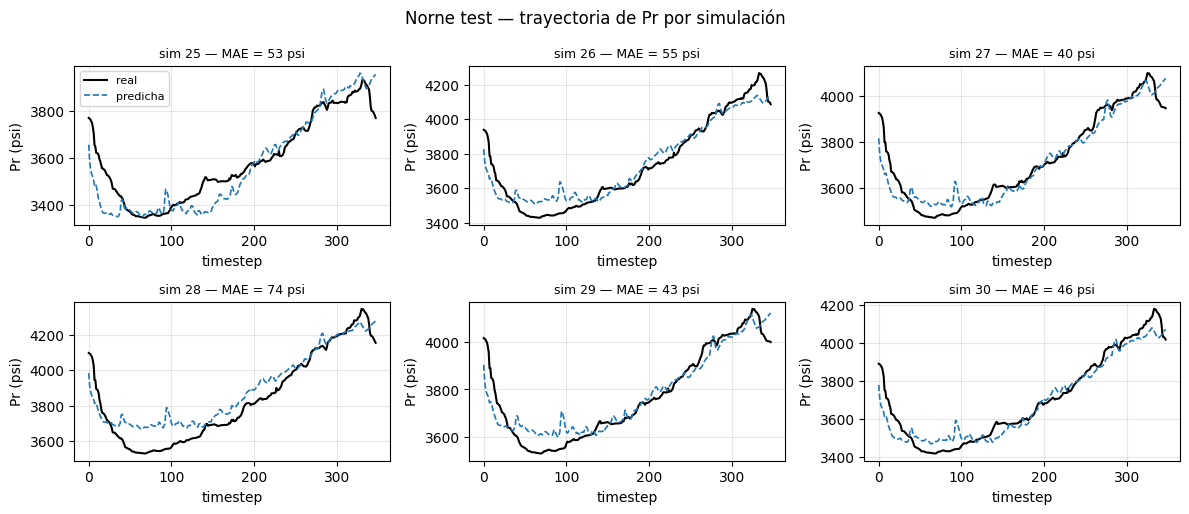

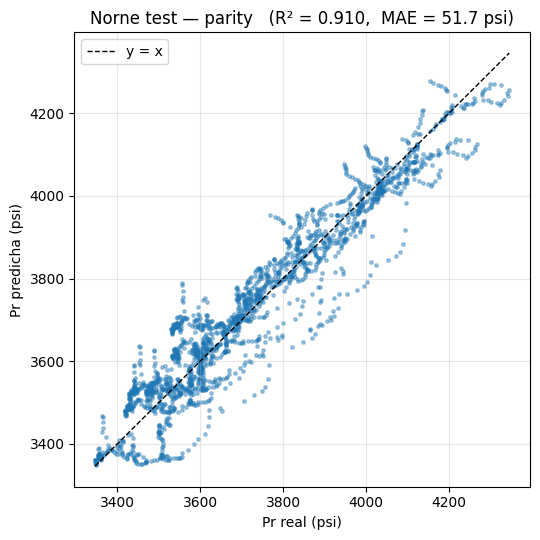

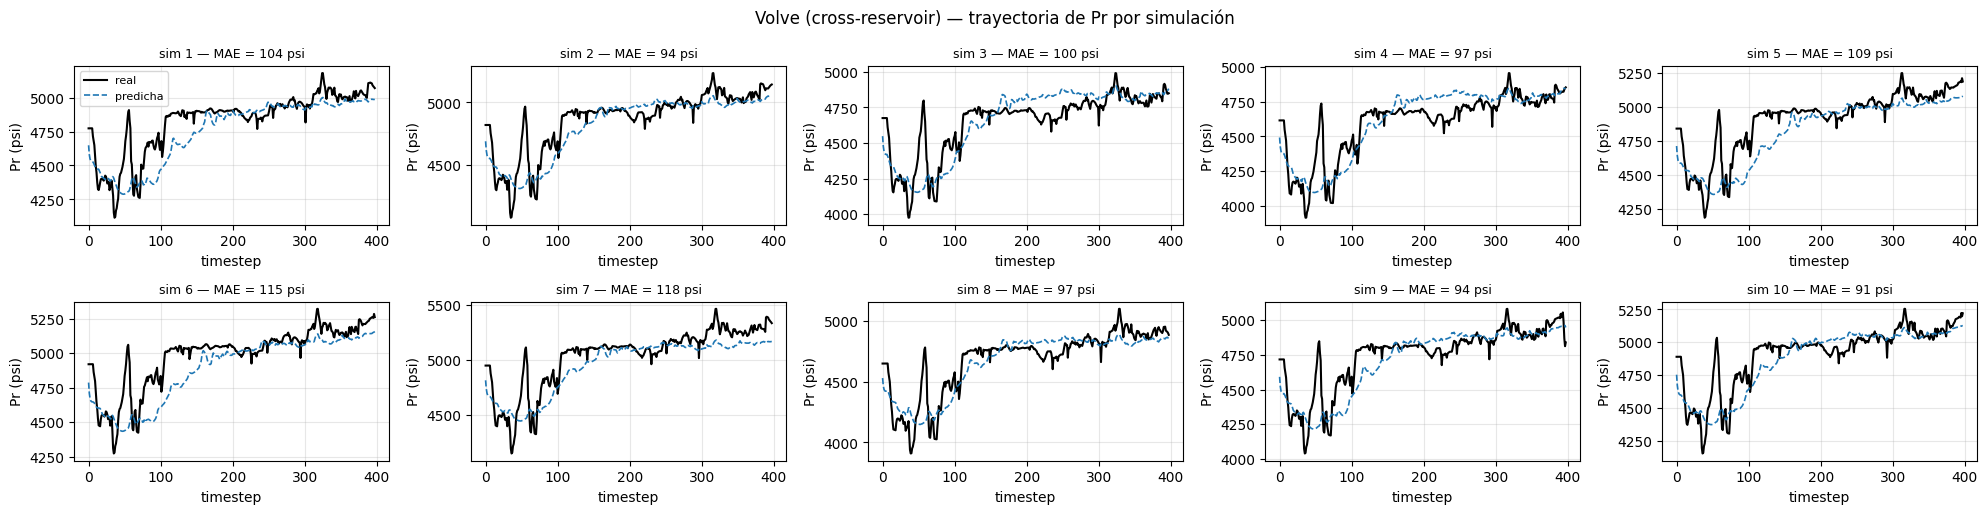

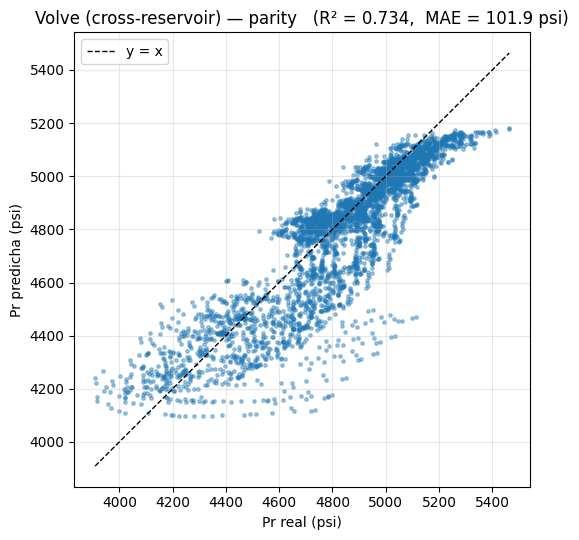

In [8]:
def plot_trajectories(X, y, sim_ids, title, n_cols=3):
    """Plotea Pr real vs predicha por simulacion en un grid."""
    Pr_predicted = model.predict(X).numpy()
    Pr_true = y.numpy()
    n_sims = len(sim_ids)
    n_rows = (n_sims + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2.6))
    for i, ax in enumerate(axes.flat):
        if i >= n_sims:
            ax.set_visible(False)
            continue
        ax.plot(Pr_true[i], color="black", lw=1.5, label="real")
        ax.plot(Pr_predicted[i], color="C0", lw=1.2, linestyle="--", label="predicha")
        mae_sim = mean_absolute_error(Pr_true[i], Pr_predicted[i])
        ax.set_title(f"sim {sim_ids[i]} — MAE = {mae_sim:.0f} psi", fontsize=9)
        ax.set_xlabel("timestep"); ax.set_ylabel("Pr (psi)"); ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8)
    fig.suptitle(f"{title} — trayectoria de Pr por simulación")
    plt.tight_layout()
    plt.show()


def plot_parity(X, y, title):
    """Plotea Pr real vs Pr predicha como scatter, con la diagonal y = x de referencia."""
    Pr_predicted = model.predict(X).numpy().ravel()
    Pr_true = y.numpy().ravel()

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(Pr_true, Pr_predicted, s=6, alpha=0.4, color="C0")
    lo, hi = min(Pr_true.min(), Pr_predicted.min()), max(Pr_true.max(), Pr_predicted.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
    r2 = r2_score(Pr_true, Pr_predicted); mae = mean_absolute_error(Pr_true, Pr_predicted)
    ax.set_xlabel("Pr real (psi)"); ax.set_ylabel("Pr predicha (psi)")
    ax.set_title(f"{title} — parity   (R² = {r2:.3f},  MAE = {mae:.1f} psi)")
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    plt.show()


plot_trajectories(X_test, y_test, sim_ids_test, "Norne test")
plot_parity(X_test, y_test, "Norne test")

plot_trajectories(X_volve, y_volve, sim_ids_volve, "Volve (cross-reservoir)", n_cols=5)
plot_parity(X_volve, y_volve, "Volve (cross-reservoir)")
